# Training ANI from scratch on rMD17 (paracetamol)

This trains the `xnns` **ANI** model, the AEV descriptor of Smith et al.
(*Chem. Sci.* 2017) feeding one neural network per element, from scratch on a
real H/C/N/O molecule, and reproduces the paper's headline demonstrations at
small scale:

* an **energy/force parity** plot vs DFT (paper Fig. 4), and
* a **smooth 1-D potential-energy scan** (paper Fig. 7), the property that makes
  ANI usable for MD.

We use [rMD17](https://doi.org/10.1021/acs.jctc.9b00181) **paracetamol**
(C₈H₉NO₂) because it exercises all four ANI elements and downloads in seconds
through the `xnns` hub. (The 20 M-conformation ANI-1 training set itself is also
in the hub: `load_dataset("ani1")`; see `ani1_dataset.ipynb`.)

Run with the **`xnns`** kernel.

## 0. Setup and data

In [1]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

from xnns.common.data import load_dataset

CUTOFF = 5.2                       # ANI-1x radial cutoff (>= angular 3.5)
splits = load_dataset("rmd17", molecule="paracetamol",
                      n_train=1000, n_test=400, cutoff=None)
train_structs, test_structs = splits["train"], splits["test"]
print(f"train {len(train_structs)}  test {len(test_structs)}")
Z0 = train_structs[0]["atomic_numbers"]
print("elements:", sorted(set(int(z) for z in Z0)), " atoms/mol:", len(Z0))

rmd17:paracetamol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:paracetamol test:   0%|          | 0/400 [00:00<?, ? struct/s]

train 1000  test 400
elements: [1, 6, 7, 8]  atoms/mol: 20


## 1. Self atomic energies (ANI's `EnergyShifter`)

ANI predicts the energy *relative* to per-element self energies, fit here by
least squares $E \approx \sum_Z n_Z\,e_Z$ and subtracted from the targets. The
network then learns the small residual, the chemically interesting part, which
also keeps the fit numerically well conditioned.

In [2]:
SPECIES = [1, 6, 7, 8]
counts = np.array([[np.sum(s["atomic_numbers"] == z) for z in SPECIES]
                   for s in train_structs], dtype=float)
E_train = np.array([s["energy"] for s in train_structs])
sae, *_ = np.linalg.lstsq(counts, E_train, rcond=None)
print("self energies (eV):", {z: round(float(e), 3) for z, e in zip(SPECIES, sae)})

def subtract_sae(structs):
    for s in structs:
        n = np.array([np.sum(s["atomic_numbers"] == z) for z in SPECIES])
        s["energy"] = float(s["energy"] - n @ sae)

subtract_sae(train_structs); subtract_sae(test_structs)
resid = np.array([s["energy"] for s in train_structs])
print(f"residual energy: mean {resid.mean():.3f} eV  std {resid.std():.3f} eV")

self energies (eV): {1: -839.943, 6: -746.616, 7: -93.327, 8: -186.654}
residual energy: mean -0.000 eV  std 0.271 eV


## 2. Build the ANI model and train

We use the ANI-1x AEV grid (384-length) with a compact per-element MLP and the
`CELU` activation, trained on energies **and** forces (forces come for free via
autograd through the `ForceStressOutput` wrapper the `Trainer` adds).

In [3]:
from torch.utils.data import Subset
from xnns.common.data import AtomicDataset
from xnns.common.config import Config, ModelConfig, DataConfig, OptimConfig
from xnns.common.train import Trainer

EPOCHS, BS, LR = 80, 32, 1e-3

train_ds = AtomicDataset(train_structs, CUTOFF)
test_ds = AtomicDataset(test_structs, CUTOFF)
n_val = 100
val_idx = list(range(n_val))
tr_idx = list(range(n_val, len(train_ds)))

cfg = Config(
    model=ModelConfig(name="ani", cutoff=CUTOFF,
                      extra={"species": SPECIES, "hidden": [128, 128, 64],
                             "activation": "celu"}),
    data=DataConfig(cutoff=CUTOFF, batch_size=BS),
    optim=OptimConfig(lr=LR, epochs=EPOCHS, energy_weight=1.0,
                      force_weight=10.0, scheduler="plateau"),
    output_dir="runs/ani_rmd17",
)

trainer = Trainer(cfg, Subset(train_ds, tr_idx), Subset(train_ds, val_idx), test_ds)
n_params = sum(p.numel() for p in trainer.module.parameters())
print(f"ANI parameters: {n_params:,}  |  device: {trainer.device}")

hist = {"train": [], "val": []}
trainer._log = lambda ep, tr, va: (hist["train"].append(tr.get("loss")),
                                   hist["val"].append(va.get("loss")))
t0 = time.time()
metrics = trainer.fit()
print(f"trained {EPOCHS} epochs in {time.time()-t0:.1f}s | test loss {metrics['test']['loss']:.4e}")

ANI parameters: 296,452  |  device: cuda


test loss 3.2432e-02
trained 80 epochs in 111.0s | test loss 3.2432e-02


## 3. Learning curves

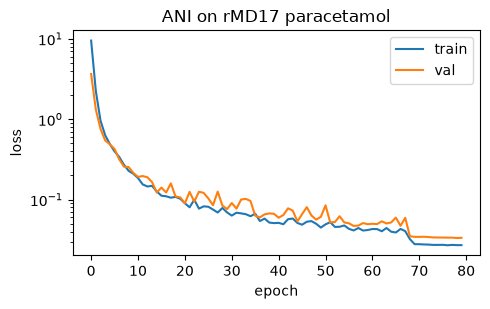

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(hist["train"], label="train")
ax.plot(hist["val"], label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("ANI on rMD17 paracetamol"); ax.legend(); fig.tight_layout()
fig.savefig("ani_loss_curves.png", dpi=110); plt.show()

## 4. Energy & force parity vs DFT (paper Fig. 4)

Predict on the held-out test set and compare to reference DFT. We report the
energy RMSE in meV and kcal/mol (the paper's unit).

energy RMSE: 31.23 meV  (0.720 kcal/mol)
force  RMSE: 57.1 meV/A  (1.317 kcal/mol/A)


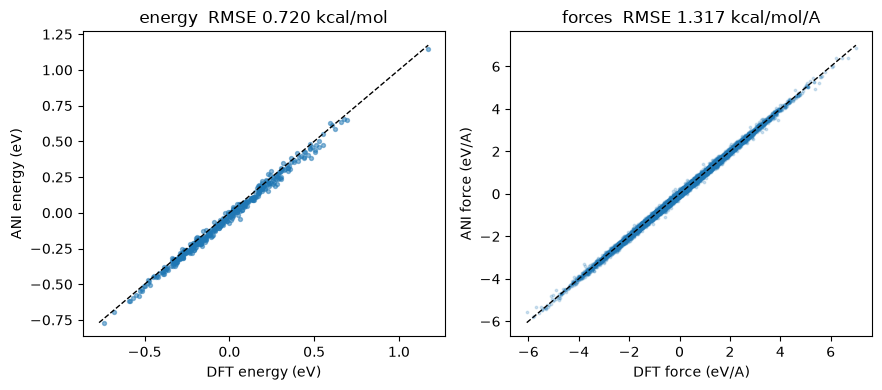

In [5]:
from torch.utils.data import DataLoader
from xnns.common.data import collate

model = trainer.model.eval()
device = trainer.device
EV2KCAL = 23.060541945329334

E_pred, E_ref, F_pred, F_ref = [], [], [], []
loader = DataLoader(test_ds, batch_size=32, collate_fn=collate)
for batch in loader:
    batch = batch.to(device)
    out = model(batch)
    E_pred.append(out["energy"].detach().cpu().numpy())
    E_ref.append(batch.energy.detach().cpu().numpy())
    F_pred.append(out["forces"].detach().cpu().numpy())
    F_ref.append(batch.forces.detach().cpu().numpy())
E_pred, E_ref = np.concatenate(E_pred), np.concatenate(E_ref)
F_pred, F_ref = np.concatenate(F_pred), np.concatenate(F_ref)

e_rmse = np.sqrt(np.mean((E_pred - E_ref) ** 2))
f_rmse = np.sqrt(np.mean((F_pred - F_ref) ** 2))
print(f"energy RMSE: {e_rmse*1e3:.2f} meV  ({e_rmse*EV2KCAL:.3f} kcal/mol)")
print(f"force  RMSE: {f_rmse*1e3:.1f} meV/A  ({f_rmse*EV2KCAL:.3f} kcal/mol/A)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.scatter(E_ref, E_pred, s=8, alpha=0.5)
lim = [min(E_ref.min(), E_pred.min()), max(E_ref.max(), E_pred.max())]
a1.plot(lim, lim, "k--", lw=1)
a1.set_xlabel("DFT energy (eV)"); a1.set_ylabel("ANI energy (eV)")
a1.set_title(f"energy  RMSE {e_rmse*EV2KCAL:.3f} kcal/mol")
a2.scatter(F_ref.ravel(), F_pred.ravel(), s=3, alpha=0.2)
lim = [F_ref.min(), F_ref.max()]
a2.plot(lim, lim, "k--", lw=1)
a2.set_xlabel("DFT force (eV/A)"); a2.set_ylabel("ANI force (eV/A)")
a2.set_title(f"forces  RMSE {f_rmse*EV2KCAL:.3f} kcal/mol/A")
fig.tight_layout(); fig.savefig("ani_parity.png", dpi=110); plt.show()

## 5. A smooth 1-D potential-energy scan (paper Fig. 7)

The value of ANI over semi-empirical methods is a **smooth, differentiable**
surface. We take a test geometry and stretch its first C–N bond, evaluating the
trained ANI energy along the scan. A smooth, single-well curve (not a jagged
one) is what enables stable MD.

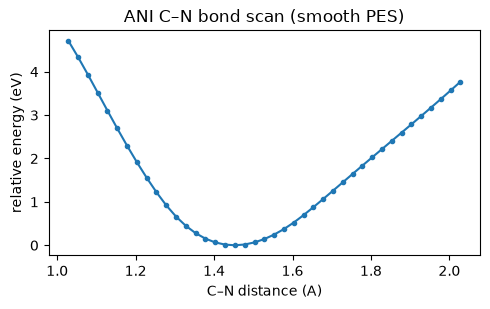

In [6]:
from xnns.common.data.neighborlist import build_neighbor_list
from xnns.common.data import AtomicGraph

s = test_structs[0]
Z = torch.tensor(s["atomic_numbers"], dtype=torch.long)
pos0 = torch.tensor(s["pos"], dtype=torch.float64)

# pick a C(6)-N(7) bonded pair
Cs = (Z == 6).nonzero().flatten(); N = (Z == 7).nonzero().flatten()[0]
d = torch.linalg.norm(pos0[Cs] - pos0[N], dim=1)
i, j = int(Cs[d.argmin()]), int(N)          # closest C to the N
axis = (pos0[j] - pos0[i]); axis = axis / axis.norm()
r0 = torch.linalg.norm(pos0[j] - pos0[i]).item()

scan = np.linspace(-0.4, 0.6, 41)
energies = []
for dr in scan:
    pos = pos0.clone(); pos[j] = pos[j] + dr * axis
    ei, cs = build_neighbor_list(pos, CUTOFF)
    g = AtomicGraph(pos=pos.to(device), atomic_numbers=Z.to(device),
                    edge_index=ei.to(device), cell_shifts=cs.to(device),
                    batch=torch.zeros(len(Z), dtype=torch.long, device=device),
                    n_atoms=torch.tensor([len(Z)], device=device))
    with torch.no_grad():
        energies.append(model(g)["energy"].item())
energies = np.array(energies) - min(energies)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(r0 + scan, energies, "o-", ms=3)
ax.set_xlabel("C–N distance (A)"); ax.set_ylabel("relative energy (eV)")
ax.set_title("ANI C–N bond scan (smooth PES)"); fig.tight_layout()
fig.savefig("ani_bond_scan.png", dpi=110); plt.show()

## Summary

From scratch on 900 paracetamol conformations, `xnns` ANI reaches chemical-scale
energy/force accuracy and produces a smooth potential-energy surface: the two
properties the ANI-1 paper emphasises. The same model, at full scale on the
`load_dataset("ani1")` training set and the published network widths
(`ANI.ani1x()`), is the ANI-1x potential verified element-for-element against
torchani in `examples/fidelity_checks/ani_verification.ipynb`.